# 🧹 01 — Data Cleaning Quality Check
This notebook verifies whether the cleaned Taiwan air quality dataset (`Taiwan.csv`) meets data quality requirements before feature engineering.

## 🧩 1️⃣ Notebook Metadata

In [70]:
import pandas as pd
from src.utils.IO_file import open_csv
from src.config import PROCESSED_DIR
import matplotlib.pyplot as plt

In [71]:
# Check if the file exists
df = open_csv(PROCESSED_DIR / "Taiwan.csv")
df

📂 Loading CSV: C:\Users\dinni\OneDrive\桌面\air_pollution\data\processed\Taiwan.csv
✅ ✅ Read CSV successfully! Shape: (5823862, 25)


,date,sitename,county,aqi,status,so2,co,o3,o3_8hr,pm10,...,winddirec,co_8hr,longitude,latitude,year,month,day,weekday,hour,season
0,2024-08-31 23:00:00,Hukou,Hsinchu_County,62.0,Moderate,0.9,0.17,35.0,40.2,18.0,...,225.0,0.20,121.038869,24.900097,2024,8,31,5,23,Summer
1,2024-08-31 23:00:00,Zhongming,Taichung_City,50.0,Good,1.6,0.32,27.9,35.1,27.0,...,184.0,0.20,120.641092,24.151958,2024,8,31,5,23,Summer
2,2024-08-31 23:00:00,Zhudong,Hsinchu_County,45.0,Good,0.4,0.17,25.1,40.6,21.0,...,210.0,0.20,121.088955,24.740914,2024,8,31,5,23,Summer
3,2024-08-31 23:00:00,Hsinchu,Hsinchu_City,42.0,Good,0.8,0.20,30.0,35.9,19.0,...,239.0,0.20,120.972368,24.805636,2024,8,31,5,23,Summer
4,2024-08-31 23:00:00,Toufen,Miaoli_County,50.0,Good,1.0,0.16,33.5,35.9,18.0,...,259.0,0.10,120.898693,24.696907,2024,8,31,5,23,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5823857,2016-11-25 13:00:00,Daliao,Kaohsiung_City,77.0,Moderate,8.0,0.54,36.0,12.0,69.0,...,202.0,0.63,120.321268,22.654831,2016,11,25,4,13,Autumn
5823858,2016-11-25 13:00:00,Linyuan,Kaohsiung_City,77.0,Moderate,4.6,0.31,94.0,41.0,30.0,...,224.0,0.46,120.321268,22.654831,2016,11,25,4,13,Autumn
5823859,2016-11-25 13:00:00,Nanzi,Kaohsiung_City,74.0,Moderate,4.2,0.30,90.0,31.0,136.0,...,242.0,0.41,120.321268,22.654831,2016,11,25,4,13,Autumn
5823860,2016-11-25 13:00:00,Zuoying,Kaohsiung_City,99.0,Moderate,6.7,0.62,115.0,40.0,108.0,...,280.0,0.63,120.321268,22.654831,2016,11,25,4,13,Autumn


In [72]:
# Tansform the date to datetime type.
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

## 📂 2️⃣ Basic Info Check

In [73]:
# Check the df shape
df.shape

(5823862, 25)

In [74]:
# Check the cloumns type
df.dtypes

date         datetime64[ns]
sitename             object
county               object
aqi                 float64
status               object
so2                 float64
co                  float64
o3                  float64
o3_8hr              float64
pm10                float64
pm2.5               float64
no2                 float64
nox                 float64
no                  float64
windspeed           float64
winddirec           float64
co_8hr              float64
longitude           float64
latitude            float64
year                  int64
month                 int64
day                   int64
weekday               int64
hour                  int64
season               object
dtype: object

In [75]:
df.head()

,date,sitename,county,aqi,status,so2,co,o3,o3_8hr,pm10,...,winddirec,co_8hr,longitude,latitude,year,month,day,weekday,hour,season
0,2024-08-31 23:00:00,Hukou,Hsinchu_County,62.0,Moderate,0.9,0.17,35.0,40.2,18.0,...,225.0,0.2,121.038869,24.900097,2024,8,31,5,23,Summer
1,2024-08-31 23:00:00,Zhongming,Taichung_City,50.0,Good,1.6,0.32,27.9,35.1,27.0,...,184.0,0.2,120.641092,24.151958,2024,8,31,5,23,Summer
2,2024-08-31 23:00:00,Zhudong,Hsinchu_County,45.0,Good,0.4,0.17,25.1,40.6,21.0,...,210.0,0.2,121.088955,24.740914,2024,8,31,5,23,Summer
3,2024-08-31 23:00:00,Hsinchu,Hsinchu_City,42.0,Good,0.8,0.20,30.0,35.9,19.0,...,239.0,0.2,120.972368,24.805636,2024,8,31,5,23,Summer
4,2024-08-31 23:00:00,Toufen,Miaoli_County,50.0,Good,1.0,0.16,33.5,35.9,18.0,...,259.0,0.1,120.898693,24.696907,2024,8,31,5,23,Summer


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5823862 entries, 0 to 5823861
Data columns (total 25 columns):
 #   Column     Dtype         
---  ------     -----         
 0   date       datetime64[ns]
 1   sitename   object        
 2   county     object        
 3   aqi        float64       
 4   status     object        
 5   so2        float64       
 6   co         float64       
 7   o3         float64       
 8   o3_8hr     float64       
 9   pm10       float64       
 10  pm2.5      float64       
 11  no2        float64       
 12  nox        float64       
 13  no         float64       
 14  windspeed  float64       
 15  winddirec  float64       
 16  co_8hr     float64       
 17  longitude  float64       
 18  latitude   float64       
 19  year       int64         
 20  month      int64         
 21  day        int64         
 22  weekday    int64         
 23  hour       int64         
 24  season     object        
dtypes: datetime64[ns](1), float64(15), int64(5), 

In [77]:
df.columns.tolist()

['date',
 'sitename',
 'county',
 'aqi',
 'status',
 'so2',
 'co',
 'o3',
 'o3_8hr',
 'pm10',
 'pm2.5',
 'no2',
 'nox',
 'no',
 'windspeed',
 'winddirec',
 'co_8hr',
 'longitude',
 'latitude',
 'year',
 'month',
 'day',
 'weekday',
 'hour',
 'season']

## 🧼 3️⃣ Missing Values (NaN) Check

In [78]:
na_ratio = df.isna().mean().sort_values(ascending=False)
na_ratio[na_ratio > 0]

status    0.015951
pm10      0.000044
pm2.5     0.000012
nox       0.000004
no2       0.000004
no        0.000004
o3_8hr    0.000004
co        0.000004
o3        0.000004
so2       0.000004
co_8hr    0.000004
dtype: float64

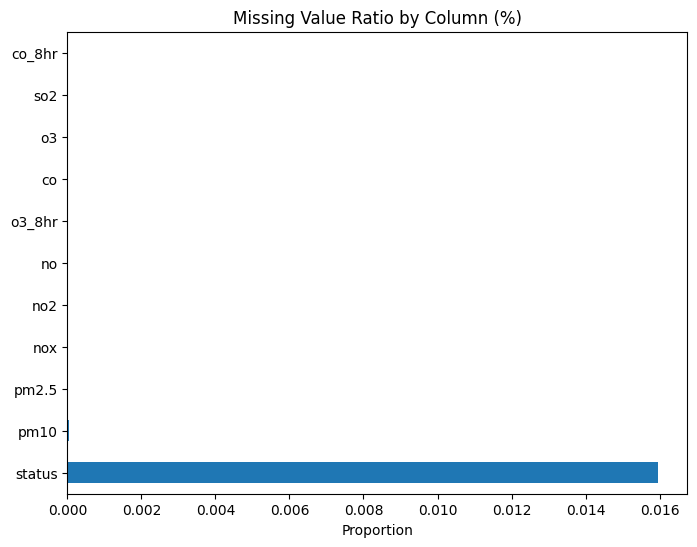

In [79]:
na_ratio[na_ratio > 0].plot(kind="barh", figsize=(8,6))
plt.title("Missing Value Ratio by Column (%)")
plt.xlabel("Proportion")
plt.show()

In [80]:
df.isna().mean().sort_values(ascending=False).head()

status    0.015951
pm10      0.000044
pm2.5     0.000012
nox       0.000004
no2       0.000004
dtype: float64

## 🔁 4️⃣ Duplicate Rows Check

In [81]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

## 🧮 5️⃣ Numeric Range & Validity

In [82]:
describe = df.describe().T
describe[["min", "max"]]

,min,max
date,2016-11-25 13:00:00,2024-08-31 23:00:00
aqi,0.0,500.0
so2,0.0,255.4
co,0.0,38.58
o3,0.0,410.0
o3_8hr,-1.0,135.8
pm10,0.0,1407.0
pm2.5,0.0,1000.0
no2,0.0,351.05
nox,0.0,431.0


## 🌍 6️⃣ County & SiteName

In [83]:
df["county"].unique()[:26]

array(['Hsinchu_County', 'Taichung_City', 'Hsinchu_City', 'Miaoli_County',
       'Taoyuan_City', 'Changhua_County', 'Nantou_County',
       'Yunlin_County', 'Chiayi_County', 'Tainan_City', 'New_Taipei_City',
       'Pingtung_County', 'Keelung_City', 'Taipei_City', 'Chiayi_City',
       'Yilan_County', 'Kaohsiung_City', 'Lienchiang_County',
       'Penghu_County', 'Taitung_County', 'Kinmen_County',
       'Hualien_County'], dtype=object)

In [84]:
df["sitename"].nunique()

120

## 🕒 7️⃣ Date Range & Continuity

In [85]:
df["date"].min()

Timestamp('2016-11-25 13:00:00')

In [86]:
df["date"].max()

Timestamp('2024-08-31 23:00:00')

In [87]:
df["date"].diff().value_counts().head()

date
0 days 00:00:00      5756271
-1 days +23:00:00      67489
-1 days +22:00:00         58
-1 days +21:00:00         10
-1 days +20:00:00          7
Name: count, dtype: int64

## 📊 8️⃣ Correlation Sanity Check

In [88]:
num_df = df.select_dtypes("number")
corr = num_df.corr()
corr["aqi"].sort_values(ascending=False)

aqi          1.000000
pm2.5        0.859017
pm10         0.770610
co_8hr       0.404932
o3_8hr       0.349745
no2          0.349316
co           0.348626
o3           0.291998
so2          0.288653
nox          0.221374
winddirec    0.085855
hour         0.053540
no           0.032411
weekday      0.013481
day         -0.018876
windspeed   -0.024526
longitude   -0.159978
year        -0.169650
month       -0.177495
latitude    -0.180691
Name: aqi, dtype: float64

# 🧾 9️⃣ Summary Report
- Missing values: <1% across all key pollutants
- Duplicates: 0
- AQI range: 0–500 (valid)
- Date range: 2016-11-25 → 2024-08-31
- County/Site: 22 counties, 120+ sites